# **Simulation Hedy 2025**

Team: TU Wien Space Team \
Project: Lamarr \
Rocket: Hedy


## Installs

In this section all needed libraries are installed and the needed classes imported

In [2]:
%pip install rocketpy==1.11.0

Defaulting to user installation because normal site-packages is not writeable
  Attempting uninstall: rocketpy
    Found existing installation: rocketpy 1.10.0
    Uninstalling rocketpy-1.10.0:
      Successfully uninstalled rocketpy-1.10.0
Note: you may need to restart the kernel to use updated packages.


In [119]:
%pip install CoolProp

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
from rocketpy import Environment, SolidMotor, Rocket, Flight, Fluid, LiquidMotor, CylindricalTank, MassFlowRateBasedTank, TrapezoidalFins, FreeFormFins, EllipticalFins, RailButtons, NoseCone, Tail, Parachute
from math import exp
from math import pi
import datetime
import CoolProp.CoolProp as CP
from CoolProp.CoolProp import PropsSI
from rocketpy.mathutils import Function
import sys
import itertools
import numpy as np
from datetime import datetime, timedelta

# Simulation

## Configuration

The length unit chosen here is millimeters to keep the values more readable. If necessary, values should be converted accordingly.

Config rules:

#comment

date=(2025, 10, 12, 17, 00, 00)                                                 #tuple

fins_shape_points=((0,0),(0.250,-0.012),(0.250, 0.108),(0.195, 0.108),(0,0))    #tuple of tuples

fins_span=110..120                                                              #range with increments of 1

holddown_time=1.1..1.5                                                          #range with increments of 0.1

fins_sweep_length=193, 180, 200                                                 # variable with discrete values (integer)

thrust=thrust_euroc_launch.csv,thrust.csv, thrust_08_25.csv                     #variable with discrete values (string)

everything else is a constant
latitude=39.232465                                                              #constant


In [77]:
def float_range(start, stop, step=1):
    while start <= stop:
        yield start
        start += step

def parse_value(value_str):
    """Parse a value into constant or list of values."""
    value_str = value_str.strip()

    # Tuple of tuples
    # TODO accept tuples of tuples as variables
    if "((" in value_str and "))" in value_str:
        value_str = value_str.strip("()")
        items = value_str.split("),(")
        parsed_items = []
        for item in items:
            item = item.strip("()")
            sub_items = [v.strip() for v in item.split(",")]
            sub_parsed_items = []
            for sub_item in sub_items:
                try:
                    n = float(sub_item)
                    sub_parsed_items.append(int(n) if n.is_integer() else n)
                except ValueError:
                    sub_parsed_items.append(sub_item)
            parsed_items.append(tuple(sub_parsed_items))
        return tuple(parsed_items)
    
    # Tuple of values
    # TODO accept tuples as variables
    if "(" in value_str and ")" in value_str:
        value_str = value_str.strip("()")
        items = [v.strip() for v in value_str.split(",")]
        parsed_items = []
        for item in items:
            try:
                n = float(item)
                parsed_items.append(int(n) if n.is_integer() else n)
            except ValueError:
                parsed_items.append(item)
        return tuple(parsed_items)
    
    # Range: a..b
    if ".." in value_str:
        start, end = map(float, value_str.split(".."))
        if start.is_integer() and end.is_integer():
            start, end = int(start), int(end)
            return list(range(start, end + 1))
        return list(float_range(start, end, 0.1))

    # Comma-separated variable values
    if "," in value_str:
        items = [v.strip() for v in value_str.split(",")]
        parsed_items = []
        for item in items:
            try:
                n = float(item)
                parsed_items.append(int(n) if n.is_integer() else n)
            except ValueError:
                parsed_items.append(item)
        return parsed_items

    # Otherwise a constant (single value)
    try:
        # Convert to float or int where possible
        n = float(value_str)
        return int(n) if n.is_integer() else n
    except ValueError:
        return value_str  # string constant


def parse_config(path):
    constants = {}
    variables = {}

    with open(path) as f:
        for line in f:
            line = line.split("#")[0].strip()  # remove comments
            if not line:
                continue
            try:
                name, value_str = map(str.strip, line.split("=", 1))
            except ValueError:
                # terminate program with error message
                print(f"Error parsing line: '{line}'. Missing '=' sign.")
                sys.exit(100)
                
            parsed = parse_value(value_str)

            # Variable = if parsed is a list
            if isinstance(parsed, list):
                variables[name] = parsed
            else:
                constants[name] = parsed

    return constants, variables

def generate_objects(constants, variables):
    names = list(variables.keys())
    value_lists = [variables[n] for n in names]

    for combo in itertools.product(*value_lists):
        obj = dict(constants)
        obj.update(zip(names, combo))
        yield obj

# Error handling for = missing in config.txt
constants, variables = parse_config("config.txt")

all_objects = list(generate_objects(constants, variables))

#for obj in all_objects:
#    print(obj)
print("VARIABLES")
for var in variables:
    print(var)
#names = list(variables.keys())
#print([variables[n] for n in names])
print()
print("///////////////////////////////////////")
print()
print("CONSTANTS")
for const in constants:
    print(const)
#names = list(constants.keys())
#print([constants[n] for n in names])

VARIABLES
environment_envType
thrust

///////////////////////////////////////

CONSTANTS
holddown_time
nitrogen_tank_length
nitrogen_tank_CG_ethanol
nitrogen_tank_CG_lox
nitrogen_tank_outer_diameter
nitrogen_tank_volume
nitrogen_tank_massflow
ethanol_tank_length
ethanol_tank_CG
ethanol_tank_outer_diameter
ethanol_tank_volume
ethanol_tank_massflow
lox_tank_length
lox_tank_CG
lox_tank_outer_diameter
lox_tank_volume
lox_tank_massflow
nozzle_diameter
nozzle_position
rocket_weight
rocket_length
rocket_CG
rocket_moment_of_intertia_Z
rocket_moment_of_intertia_XY
rocket_wall_thickness
rocket_diameter
nosecone_length
nosecone_kind
railbuttons_upper
railbuttons_lower
tailcone_diameter
tailcone_length
tailcone_cylindrical_height
fins_name
fins_amount
fins_root_chord
fins_tip_chord
fins_span
fins_sweep_length
fins_position
fins_shape_points
main_cd_s
main_trigger
drogue_cd_s
drogue_trigger
flight_rail_length
flight_inclination
flight_heading


In [78]:
def generate_combinations(params):
    for p in params:
        if p not in constants and p not in variables:
            print(f"Error: Parameter '{p}' not found in constants or variables.")
            sys.exit(102)

    var_params = [p for p in params if p in variables]
    if not var_params:  # all constants
        yield {p: constants[p] for p in params}
        return

    value_lists = [variables[p] for p in var_params]

    for combo in itertools.product(*value_lists):
        values = {p: constants.get(p) for p in params}
        values.update(dict(zip(var_params, combo)))
        yield values

def register(name, objects):
    if len(objects) == 1:
        constants[name] = objects[0]
    else:
        variables[name] = objects

def fill_parameters(parameter_list, string):
   parameter_list.extend(p for p in constants if p.startswith(string))
   parameter_list.extend(p for p in variables if p.startswith(string))

def check_required(parameter_list, required, kind = None):
    if kind is not None:
        required = [kind + "_" + item for item in required]
    missing = set(required) - set(parameter_list)
    if missing:
        raise ValueError(f"Missing required {kind} parameters: {missing}")

def add_defaults(parameter_list, defaults, kind = None):
    for k, v in defaults.items():
        if kind is not None:
            k = kind + "_" + k
        if k not in constants and k not in variables:
            constants[k] = v
            parameter_list.append(k)

In [79]:
def render_meta(meta, indent=0):
    lines = []
    pad = " " * indent
    for k, v in meta.items():
        lines.append(f"{pad}|  {k}")
        if hasattr(v, "_meta"):
            lines.extend(render_meta(v._meta, indent + 3))
        else:
            lines[-1] += f" = {v}"
    return lines


def obj_to_pretty_label(obj):
    header = obj.name if hasattr(obj, "name") else obj.__class__.__name__
    if not hasattr(obj, "_meta"):
        return header
    return "\n".join([header] + render_meta(obj._meta))

def attach_meta(obj, meta):
    obj._meta = meta
    obj.name = obj_to_pretty_label(obj)


## Environments Initialization




In this Section the environments are initialized.
*   **envForecast**: environment with the weather data from the wyoming-sounding data source at the location and date of EuRoc
*   **envNormal**: normalized environment with standard atmospheric values at the time and location of EuRoc
*   **envCostom**: custom environment with variable values for temperature and windspeed


In [80]:
#Ponte de Sor: 39.12368, -8.03333
#EUROC: 09.-15.10.2025
#possible launch date: 11.10.2025

parameter_env = []
defaults = {
    "envType" : "Forecast",
    "latitude" : 39.232465,
    "longitude" : -8.172108,
    "timezone" : "Europe/Rome",
    "date" : (datetime.now() + timedelta(days=1))
}
fill_parameters(parameter_env, "environment")
add_defaults(parameter_env, defaults, "environment")

environmentsForecast = []
environmentsNormal = []
environmentsCustom = []
environmentsReanalysis = []

enabled_env_types = []
if "environment_envType" in constants:
    val = constants["environment_envType"]
    enabled_env_types = [val] if isinstance(val, str) else list(val)
elif "environment_envType" in variables:
    val = variables["environment_envType"]
    enabled_env_types = val if isinstance(val, list) else [val]

print(enabled_env_types)

#TODO: make reanalysis (past, fixed date) and others (future, variable date) work together

if "Forecast" in enabled_env_types:
    for env_vals in generate_combinations(parameter_env):
        if "Forecast" in env_vals["environment_envType"]:
            # Environment based on forecast data
            envForecast = Environment()
            envForecast.set_location(latitude=env_vals["environment_latitude"], longitude=env_vals["environment_longitude"])
            envForecast.set_date(env_vals["environment_date"], timezone=env_vals["environment_timezone"])
            envForecast.set_elevation("Open-Elevation")
            envForecast.set_atmospheric_model(type="Forecast", file="GFS")
            # envForecast.info()
            attach_meta(envForecast, {
                k: env_vals[k]
                for k in variables
                if k in env_vals
            })
            environmentsForecast.append(envForecast)
    register("envForecast", environmentsForecast)

if "Normal" in enabled_env_types:
    for env_vals in generate_combinations(parameter_env):
        if "Normal" in env_vals["environment_envType"]:
            # Environment based on standard values
            envNormal = Environment()
            envNormal.set_location(latitude=env_vals["environment_latitude"], longitude=env_vals["environment_longitude"])
            envNormal.set_date(env_vals["environment_date"], timezone=env_vals["environment_timezone"])
            envNormal.set_elevation("Open-Elevation")
            envNormal.set_atmospheric_model(type = "standard_atmosphere")
            # envNormal.info()
            attach_meta(envNormal, {
                k: env_vals[k]
                for k in variables
                if k in env_vals
            })
            environmentsNormal.append(envNormal)
    register("envNormal", environmentsNormal)

if "Custom" in enabled_env_types:
    for env_vals in generate_combinations(parameter_env):
        if "Custom" in env_vals["environment_envType"]:
            # Environment based on Custom Data
            envCustom = Environment()
            envCustom.set_location(latitude=env_vals["environment_latitude"], longitude=env_vals["environment_longitude"])
            envCustom.set_atmospheric_model(type = "custom_atmosphere", temperature = 30 + 273.15, wind_u = lambda t:10 + (t /1000)**2, wind_v = 0)
            # envCustom.info()
            environmentsCustom.append(envCustom)
            attach_meta(envCustom, {
                k: env_vals[k]
                for k in variables
                if k in env_vals
            })
    register("envCustom", environmentsCustom)

if "Reanalysis" in enabled_env_types:
    for env_vals in generate_combinations(parameter_env):
        if "Reanalysis" in env_vals["environment_envType"]:
            # Environment based on historical data
            envReanalysis = Environment()
            envReanalysis.set_location(latitude=env_vals["environment_latitude"], longitude=env_vals["environment_longitude"])
            envReanalysis.set_elevation("Open-Elevation")
            envReanalysis.set_date((2025, 10, 12, 17, 00, 00), timezone="Europe/Lisbon")
            envReanalysis.set_atmospheric_model(
                type="Reanalysis",
                file="euroc_weather.nc",
                dictionary="ECMWF",
            )
            attach_meta(envReanalysis, {
                k: env_vals[k]
                for k in variables
                if k in env_vals
            })
            # envReanalysis.info()
            environmentsReanalysis.append(envReanalysis)
    register("envReanalysis", environmentsReanalysis)

['Forecast', 'Reanalysis']
Fetching elevation from open-elevation.com for lat=39.232465, lon=-8.172108...
Elevation received: 191.0 m


C:\Users\wattikan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\rocketpy\environment\tools.py:309: UserWarning: Exact chosen launch time is not available in the provided file, using 2026-01-14 15:00:00 UTC instead.
  warnings.warn(


Fetching elevation from open-elevation.com for lat=39.232465, lon=-8.172108...
Elevation received: 191.0 m


## Tanks / Engine



using ethanol burn time (9.225280880958138). LOX burntime is 10.662815399911576
thrust_euroc_launch.csv
using ethanol burn time (9.225280880958138). LOX burntime is 10.662815399911576
thrust_08_25.csv
using ethanol burn time (9.225280880958138). LOX burntime is 10.662815399911576
thrust.csv


C:\Users\wattikan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\rocketpy\motors\motor.py:990: UserWarning: burn_time argument (0, 8.125280880958138) is out of thrust source time range. Using thrust_source boundary times instead: (0.6, 7.8) s.
If you want to change the burn out time of the curve please use the 'reshape_thrust_curve' argument.
  warnings.warn(


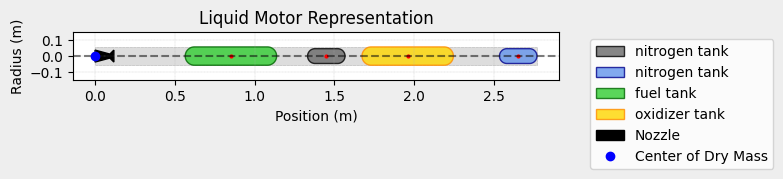

In [81]:
parameter_motor = [
                  # holddown time
                  "holddown_time",
                  
                  # nozzle
                  "nozzle_diameter",

                  # thrust
                  "thrust"]

fill_parameters(parameter_motor, "nitrogen_tank_")
fill_parameters(parameter_motor, "ethanol_tank_")
fill_parameters(parameter_motor, "lox_tank_")
fill_parameters(parameter_motor, "pressure_")
fill_parameters(parameter_motor, "temperature_")

required = [
  "length",
  "outer_diameter",
  "volume",
  "massflow"
]
check_required(parameter_motor, required, "nitrogen_tank")
check_required(parameter_motor, required, "ethanol_tank")
check_required(parameter_motor, required, "lox_tank")

required = [
  "nitrogen_tank_CG_ethanol",
  "nitrogen_tank_CG_lox",
]
check_required(parameter_motor, required)


defaults = {
  "temperature_nitrogen" : 298.15,                # K       # preset (= 25°C)
  "temperature_ethanol" : 298.15,                # K       # preset (= 25°C)
  "temperature_lox" : 93.15,                    # K       # preset (= -180°C)
  "pressure_nitrogen" : 30000000,              # Pa     # preset
  "pressure_ethanol" : 3000000,              # Pa     # preset
  "pressure_lox" : 3000000             # Pa     # preset
}

add_defaults(parameter_motor, defaults)

motors = []

for motor_vals in generate_combinations(parameter_motor):
  # Propellants

  # define density
  rho_nitrogen = CP.PropsSI("D","T",motor_vals["temperature_nitrogen"],"P|gas",motor_vals["pressure_nitrogen"],"N2")             # kg/m^3
  rho_ethanol = CP.PropsSI("D", "T|liquid", motor_vals["temperature_ethanol"], "P", motor_vals["pressure_ethanol"], "ethanol")   # kg/m^3
  rho_lox = CP.PropsSI("D", "T|liquid", motor_vals["temperature_lox"], "P", motor_vals["pressure_lox"], "oxygen")                # kg/m^3

  # define fluids
  nitrogen = Fluid(name = "N2", density = rho_nitrogen)
  ethanol = Fluid(name = "ethanol", density = rho_ethanol)
  lox = Fluid(name = "LOX", density = rho_lox)

  # define tanks geometry
  nitrogen_tank_shape = CylindricalTank(radius = motor_vals["nitrogen_tank_outer_diameter"] / 2 /1000, height = motor_vals["nitrogen_tank_length"] /1000, spherical_caps = True)
  ethanol_tank_shape = CylindricalTank(radius = motor_vals["ethanol_tank_outer_diameter"] / 2 /1000, height = motor_vals["ethanol_tank_length"] /1000, spherical_caps = True)
  lox_tank_shape = CylindricalTank(radius = motor_vals["lox_tank_outer_diameter"] / 2 /1000, height = motor_vals["lox_tank_length"] /1000, spherical_caps = True)


  m_nitrogen = motor_vals["nitrogen_tank_volume"] /1000 * rho_nitrogen                   # m
  m_ethanol = motor_vals["ethanol_tank_volume"] /1000 * rho_ethanol                      # m
  m_lox = motor_vals["lox_tank_volume"] /1000 * rho_lox                                  # m

  t_burn_nitrogen = (m_nitrogen / motor_vals["nitrogen_tank_massflow"])-0.001          # s


  t_burn_ethanol = (m_ethanol / motor_vals["ethanol_tank_massflow"])
  t_burn_lox = (m_lox / motor_vals["lox_tank_massflow"])

  if(t_burn_ethanol<t_burn_lox):
    t_burn = t_burn_ethanol
    print(f"using ethanol burn time ({t_burn_ethanol}). LOX burntime is {t_burn_lox}")
  else:
    t_burn = t_burn_lox
    print(f"using lox burn time ({t_burn_lox}). Ethanol burntime is {t_burn_ethanol}")


  #account for holddown
  t_burn -= motor_vals["holddown_time"]
  
  m_nitrogen = motor_vals["nitrogen_tank_massflow"] * t_burn + 0.0001
  m_ethanol = motor_vals["ethanol_tank_massflow"] * t_burn + 0.0001
  m_lox = motor_vals["lox_tank_massflow"] * t_burn + 0.0001

  # define tanks
  nitrogen_tank = MassFlowRateBasedTank(
      name = "nitrogen tank",
      geometry = nitrogen_tank_shape,
      flux_time = t_burn,                                 # s
      initial_liquid_mass = 0,                            # kg
      initial_gas_mass = m_nitrogen,                      # kg
      liquid_mass_flow_rate_in = 0,                       # kg/s
      liquid_mass_flow_rate_out = 0,                      # kg/s
      gas_mass_flow_rate_in = 0,                          # kg/s
      gas_mass_flow_rate_out = lambda t: motor_vals["nitrogen_tank_massflow"],   # ks/s
      liquid = Fluid(name = "liquid", density = 0.0001),  # ignore
      gas = nitrogen,
  )
  ethanol_tank = MassFlowRateBasedTank(
      name = "fuel tank",
      geometry = ethanol_tank_shape,
      flux_time = t_burn,                                 # s
      initial_liquid_mass = m_ethanol,                    # kg
      initial_gas_mass = 0,                               # kg
      liquid_mass_flow_rate_in = 0,                       # kg/s
      liquid_mass_flow_rate_out = lambda t: motor_vals["ethanol_tank_massflow"], # kg/s
      gas_mass_flow_rate_in = lambda t: motor_vals["nitrogen_tank_massflow"],    # kg/s
      gas_mass_flow_rate_out = 0,                         # kg/s
      liquid = ethanol,
      gas = nitrogen,
  )

  lox_tank = MassFlowRateBasedTank(
      name = "oxidizer tank",
      geometry = lox_tank_shape,
      flux_time = t_burn,                                 # s
      initial_liquid_mass = m_lox,                        # kg
      initial_gas_mass = 0,                               # kg
      liquid_mass_flow_rate_in = 0,                       # kg/s
      liquid_mass_flow_rate_out = lambda t: motor_vals["lox_tank_massflow"],     # kg/s
      gas_mass_flow_rate_in = lambda t: motor_vals["nitrogen_tank_massflow"],    # kg/s
      gas_mass_flow_rate_out = 0,                         # kg/s
      liquid = lox,
      gas = nitrogen,
  )

  print(motor_vals["thrust"])
  skuld = LiquidMotor(
      dry_mass = 0.0001,                  # kg
      dry_inertia = (0,0,0),              # kg*m^2
      center_of_dry_mass_position = 0,    # m

      nozzle_radius = motor_vals["nozzle_diameter"] /2 /1000, # m
      nozzle_position = 0,  # m

      thrust_source = motor_vals["thrust"],   # N
      burn_time = t_burn,                 # s
      coordinate_system_orientation = "nozzle_to_combustion_chamber"
  )

  skuld.add_tank(tank = nitrogen_tank, position   = motor_vals["nitrogen_tank_CG_ethanol"]   / 1000)
  skuld.add_tank(tank = nitrogen_tank, position   = motor_vals["nitrogen_tank_CG_lox"]       / 1000)
  skuld.add_tank(tank = ethanol_tank, position    = motor_vals["ethanol_tank_CG"]            / 1000)
  skuld.add_tank(tank = lox_tank, position        = motor_vals["lox_tank_CG"]                / 1000)

  # skuld.all_info()
  attach_meta(skuld, {
      k: motor_vals[k]
      for k in variables
      if k in motor_vals
  })
  motors.append(skuld)
register("motor", motors)
skuld.draw()

## Rocket components

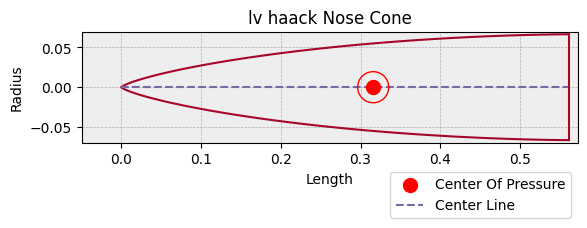

C:\Users\wattikan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\rocketpy\rocket\aero_surface\fins\free_form_fins.py:143: UserWarning: Jagged fin shape detected. This may cause small inaccuracies center of pressure and pitch moment calculations.
  warnings.warn(


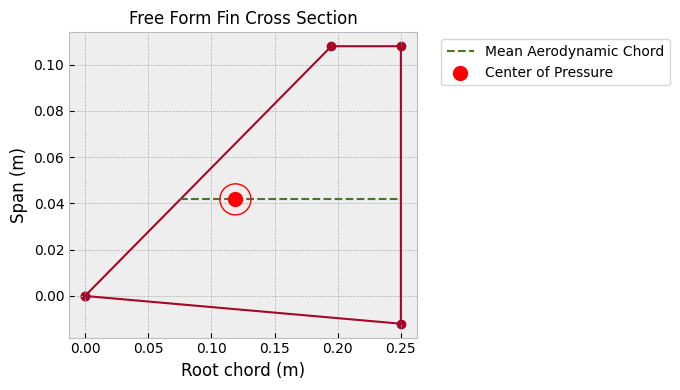

In [82]:
parameter_nosecone = ["rocket_diameter"]
required = ["length"]
fill_parameters(parameter_nosecone, "nosecone_")
check_required(parameter_nosecone, required, "nosecone")

if not parameter_nosecone.__contains__("nosecone_kind"):
    constants["nosecone_kind"] = "von karman"
    parameter_nosecone.add("nosecone_kind")

nosecones = []

for nosecone_vals in generate_combinations(parameter_nosecone):
    nosecone = NoseCone(
        length = nosecone_vals["nosecone_length"] /1000,
        base_radius = nosecone_vals["rocket_diameter"]/2 /1000,
        kind = nosecone_vals["nosecone_kind"]
    )
    attach_meta(nosecone, {
        k: nosecone_vals[k]
        for k in variables
        if k in nosecone_vals
    })
    nosecones.append(nosecone)
register("nosecone", nosecones)
nosecone.draw()


parameter_tailcone = ["rocket_diameter"]
required = ["diameter", "length"]
fill_parameters(parameter_tailcone, "tailcone_")
check_required(parameter_tailcone, required, "tailcone")

tailcones = []

for tailcone_vals in generate_combinations(parameter_tailcone):
    tailcone = Tail(
        top_radius = tailcone_vals["rocket_diameter"] /2 /1000,
        bottom_radius = tailcone_vals["tailcone_diameter"] /2 /1000,
        length = tailcone_vals["tailcone_length"] /1000,
        rocket_radius = tailcone_vals["rocket_diameter"]/2 /1000
    )
    attach_meta(tailcone, {
        k: tailcone_vals[k]
        for k in variables
        if k in tailcone_vals
    })
    tailcones.append(tailcone)
register("tailcone", tailcones)


parameter_fins = [
    # rocket
    "rocket_diameter",
    # tailcone
    "tailcone_diameter"]

defaults = {"fins_amount" : 4}

fill_parameters(parameter_fins, "fins_")


if not parameter_fins.__contains__("fins_shape_points"):
    required=[
        "root_chord",
        "tip_chord",
        "span",
        "sweep_length"
    ]
    check_required(parameter_fins, required, "fins")

add_defaults(parameter_fins, defaults)

fins = []
trapezoidal_fins = []

for fin_vals in generate_combinations(parameter_fins):
    if "fins_shape_points" in parameter_fins:
        fin_set = FreeFormFins(
            n = fin_vals["fins_amount"],
            shape_points = fin_vals["fins_shape_points"],         # m
            rocket_radius=fin_vals["tailcone_diameter"] /2 /1000,    # m
            name = "Freeform"
        )
        # fin_set.draw()
        attach_meta(fin_set, {
            k: fin_vals[k]
            for k in variables
            if k in fin_vals
        })
        fins.append(fin_set)
    else:
        trapezoidal_fin_set = TrapezoidalFins(
            n = fin_vals["fins_amount"],
            root_chord = fin_vals["fins_root_chord"] /1000,      # m
            tip_chord = fin_vals["fins_tip_chord"] /1000,        # m
            span = fin_vals["fins_span"] /1000,                  # m
            sweep_length = fin_vals["fins_sweep_length"] /1000,  # m
            name = fin_vals["fins_name"],
            rocket_radius = fin_vals["rocket_diameter"]/2 /1000 # m
        )
        # trapezoidal_fin_set.draw()
        attach_meta(trapezoidal_fin_set, {
            k: fin_vals[k]
            for k in variables
            if k in fin_vals
        })
        trapezoidal_fins.append(trapezoidal_fin_set)

if "fins_shape_points" in parameter_fins:
    register("fin_set", fins)
    fin_set.draw()
    print(fins)
else:
    register("fin_set", trapezoidal_fins)
    trapezoidal_fin_set.draw()
    print(trapezoidal_fins)


parameter_parachutes = []

required=[
    "cd_s",
    "trigger"
]

defaults = {
    "drogue_sampling_rate": 105,        # hz              # preset
    "drogue_lag": 1,                    # s               # measured
    "drogue_noise": (0, 8.3, 0.5),       # (pa, pa, pa)    # preset
    "main_sampling_rate": 105,        # hz              # preset
    "main_lag": 4,                    # s               # measured
    "main_noise": (0, 8.3, 0.5)        # (pa, pa, pa)    # preset
}

fill_parameters(parameter_parachutes, "drogue_")
fill_parameters(parameter_parachutes, "main_")

check_required(parameter_parachutes, required, "drogue")
check_required(parameter_parachutes, required, "main")

add_defaults(parameter_parachutes, defaults)


parachutes = []

for parachute_vals in generate_combinations(parameter_parachutes):
    parachute_list = {}
    parachute_list[0] = Parachute(
        name = "main",
        cd_s = parachute_vals["main_cd_s"],
        trigger = parachute_vals["main_trigger"],             # m
        sampling_rate = parachute_vals["main_sampling_rate"], # hz
        lag = parachute_vals["main_lag"],                     # s
        noise = parachute_vals["main_noise"],                 # (pa, pa, pa)
    )

    parachute_list[1] = Parachute(
        name = "drogue",
        cd_s = parachute_vals["drogue_cd_s"],
        trigger = parachute_vals["drogue_trigger"],             # m
        sampling_rate = parachute_vals["drogue_sampling_rate"], # hz
        lag = parachute_vals["drogue_lag"],                     # s
        noise = parachute_vals["drogue_noise"],                 # (pa, pa, pa)
    )
    attach_meta(parachute_list[0], {
        k: parachute_vals[k]
        for k in variables
        if k in parachute_vals
    })
    attach_meta(parachute_list[1], {
        k: parachute_vals[k]
        for k in variables
        if k in parachute_vals
    })
    parachutes.append(parachute_list)
register("parachutes", parachutes)


## Hedy

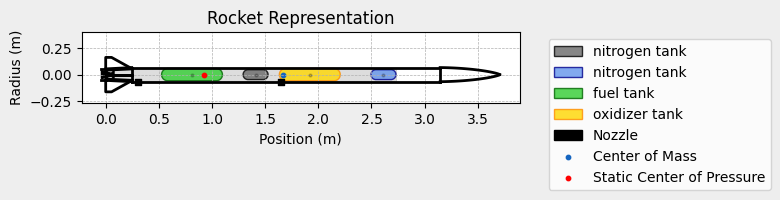

In [83]:
parameter_rockets = [
    "nozzle_position",
    "fins_position",
    "tailcone_length",
    "motor",
    "nosecone",
    "tailcone",
    "fin_set",
    "parachutes"
]

required=[
    "diameter",
    "weight",
    "CG",
    "length"
]

fill_parameters(parameter_rockets, "rocket_")
fill_parameters(parameter_rockets, "railbuttons_")
check_required(parameter_rockets, required, "rocket")

rockets = []

for rocket_vals in generate_combinations(parameter_rockets):
    hedy = Rocket(
        radius = rocket_vals["rocket_diameter"] /2 / 1000,                      # m
        mass = rocket_vals["rocket_weight"] / 1000,                                # m
        inertia = (rocket_vals["rocket_moment_of_intertia_XY"], rocket_vals["rocket_moment_of_intertia_XY"], rocket_vals["rocket_moment_of_intertia_Z"]),  # kg * m^2
        power_off_drag = "./power_off_drag.csv",
        power_on_drag = "./power_on_drag.csv",
        center_of_mass_without_motor = rocket_vals["rocket_CG"] / 1000,                # m
        coordinate_system_orientation = "tail_to_nose"
    )
    hedy.add_motor(rocket_vals["motor"], position = rocket_vals["nozzle_position"] /1000)
    hedy.set_rail_buttons(upper_button_position= rocket_vals["railbuttons_upper"] / 1000, lower_button_position=rocket_vals["railbuttons_lower"] / 1000)
    hedy.add_surfaces(surfaces=[rocket_vals["nosecone"], rocket_vals["fin_set"], rocket_vals["tailcone"]], positions=[rocket_vals["rocket_length"] / 1000, rocket_vals["fins_position"] / 1000, rocket_vals["tailcone_length"] / 1000])

    hedy.parachutes = list(rocket_vals["parachutes"].values())

    #hedy.all_info()
    attach_meta(hedy, {
        k: rocket_vals[k]
        for k in variables
        if k in rocket_vals
    })
    rockets.append(hedy)
register("rocket", rockets)

vis_args = {
    "background": "#EEEEEE",
    "tail": "black",
    "nose": "black",
    "body": "black",
    "fins": "black",
    "motor": "black",
    "buttons": "black",
    "line_width": 2.0,
}
hedy.draw(plane = 'xz', vis_args = vis_args)

## Flight

In [85]:
from os import name
from rocketpy import CompareFlights
from math import prod

#TODO: move all imports

parameter_flights = [
    "rocket"
]

required = [
    "rail_length",
    "inclination",
    "heading"
]

defaults = {
  "flight_terminate_on_apogee" : True
}

fill_parameters(parameter_flights, "flight_")
check_required(parameter_flights, required, "flight")
add_defaults(parameter_flights, defaults)

for type in enabled_env_types:
  parameter_flights.append("env" + type)


flights_normal = []
flights_forecast = []
flights_custom = []
flights_reanalysis = []

def count_combinations(params):
    return prod(
        len(variables[p]) for p in params if p in variables
    ) or 1

total = count_combinations(parameter_flights)
step = max(1, total // 10)

for i, flight_vals in enumerate(generate_combinations(parameter_flights), start=1):

  if "Normal" in enabled_env_types:
    flight_normal = Flight(
              rocket        = flight_vals["rocket"],
              environment   = flight_vals["envNormal"],
              rail_length   = flight_vals["flight_rail_length"],
              inclination   = flight_vals["flight_inclination"],
              heading       = flight_vals["flight_heading"],
              terminate_on_apogee = flight_vals["flight_terminate_on_apogee"],
              name          = "Normal"
    )
    #flight_normal.prints.out_of_rail_conditions()
    #flight_normal.prints.apogee_conditions()
    #flight_normal.prints.impact_conditions()
    #flight_normal.prints.maximum_values()
    #flight_normal.plots.trajectory_3d()
    #flight_normal.plots.stability_and_control_data()

    #flight_normal.plots.all()
    #flight_normal.prints.all()
    #flight_normal.all_info()
    attach_meta(flight_normal, {
        k: flight_vals[k]
        for k in variables
        if k in flight_vals
    })
    flights_normal.append(flight_normal)


  if "Forecast" in enabled_env_types:
    flight_forecast = Flight(
              rocket        = flight_vals["rocket"],
              environment   = flight_vals["envForecast"],
              rail_length   = flight_vals["flight_rail_length"],
              inclination   = flight_vals["flight_inclination"],
              heading       = flight_vals["flight_heading"],
              terminate_on_apogee = flight_vals["flight_terminate_on_apogee"],
              name          = "Forecast"
    )
    #flight_forecast.prints.out_of_rail_conditions()
    #flight_forecast.prints.apogee_conditions()
    #flight_forecast.prints.impact_conditions()
    #flight_forecast.prints.maximum_values()
    #flight_forecast.plots.trajectory_3d()
    #flight_forecast.plots.stability_and_control_data()

    #flight_forecast.prints.all()
    #flight_forecast.plots.all()
    #flight_forecast.all_info()
    attach_meta(flight_forecast, {
        k: flight_vals[k]
        for k in variables
        if k in flight_vals
    })
    flights_forecast.append(flight_forecast)
  if "Custom" in enabled_env_types:
    flight_custom = Flight(
              rocket        = flight_vals["rocket"],
              environment   = flight_vals["envCustom"],
              rail_length   = flight_vals["flight_rail_length"],
              inclination   = flight_vals["flight_inclination"],
              heading       = flight_vals["flight_heading"],
              terminate_on_apogee = flight_vals["flight_terminate_on_apogee"],
              name          = "Custom"
    )
    #flight_custom.prints.out_of_rail_conditions()
    #flight_custom.prints.apogee_conditions()
    #flight_custom.prints.impact_conditions()
    #flight_custom.prints.maximum_values()
    #flight_custom.plots.trajectory_3d()
    #flight_custom.plots.stability_and_control_data()

    #flight_custom.prints.all()
    #flight_custom.plots.all()
    #flight_custom.all_info()
    attach_meta(flight_custom, {
        k: flight_vals[k]
        for k in variables
        if k in flight_vals
    })
    flights_custom.append(flight_custom)
  
  if "Reanalysis" in enabled_env_types:
    flight_reanalysis = Flight(
              rocket        = flight_vals["rocket"],
              environment   = flight_vals["envReanalysis"],
              rail_length   = flight_vals["flight_rail_length"],
              inclination   = flight_vals["flight_inclination"],
              heading       = flight_vals["flight_heading"],
              terminate_on_apogee = flight_vals["flight_terminate_on_apogee"],
              name          = "Reanalysis"
    )
    #flight_reanalysis.prints.out_of_rail_conditions()
    #flight_reanalysis.prints.apogee_conditions()
    #flight_reanalysis.prints.impact_conditions()
    #flight_reanalysis.prints.maximum_values()
    #flight_reanalysis.plots.trajectory_3d()
    #flight_reanalysis.plots.stability_and_control_data()

    #flight_reanalysis.prints.all()
    #flight_reanalysis.plots.all()
    #flight_reanalysis.all_info()
    attach_meta(flight_reanalysis, {
        k: flight_vals[k]
        for k in variables
        if k in flight_vals
    })
    flights_reanalysis.append(flight_reanalysis)

  if i % step == 0 or i == total:
      print(f"{i / total:.0%}")
  
register("normal_flight", flights_normal)
register("forecast_flight", flights_forecast)
register("custom_flight", flights_custom)
register("reanalysis_flight", flights_reanalysis)
#flight_forecast.all_info()

33%
67%
100%


## Comparsion

Forecast
|  rocket
   |  motor
      |  thrust = thrust_euroc_launch.csv
Forecast
|  rocket
   |  motor
      |  thrust = thrust_08_25.csv
Forecast
|  rocket
   |  motor
      |  thrust = thrust.csv
Reanalysis
|  rocket
   |  motor
      |  thrust = thrust_euroc_launch.csv
Reanalysis
|  rocket
   |  motor
      |  thrust = thrust_08_25.csv
Reanalysis
|  rocket
   |  motor
      |  thrust = thrust.csv
Plot saved to file: 2d_xy.png
Plot saved to file: 2d_yz.png


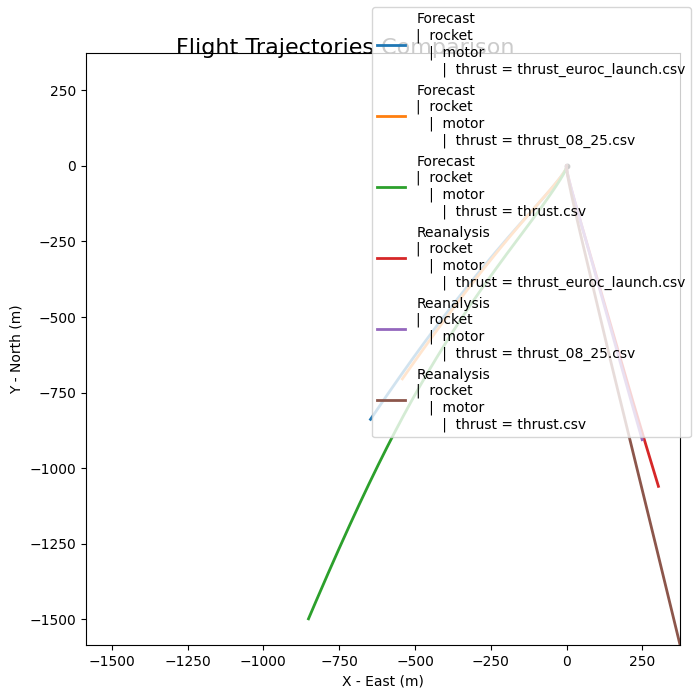

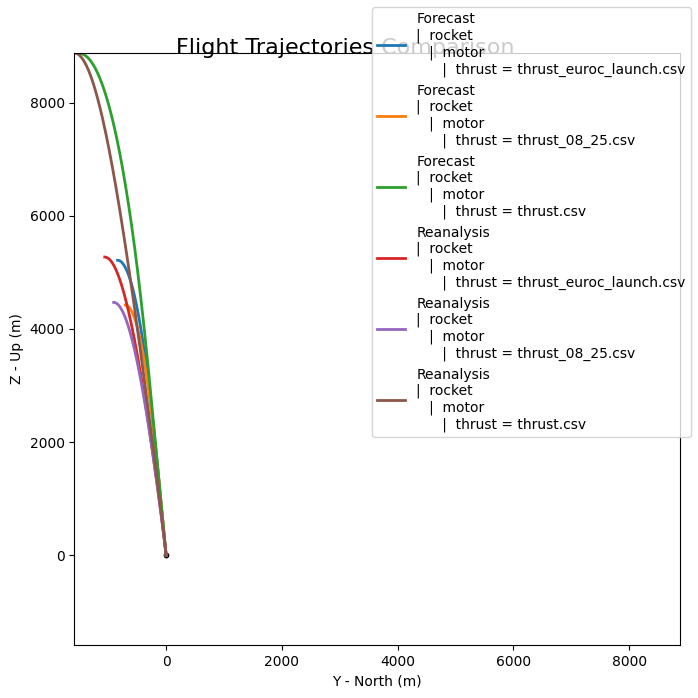

In [86]:
#TODO: add in/output, so user does not have to open the code
legend = True
all_flights = (
    flights_normal
    + flights_forecast
    + flights_custom
    + flights_reanalysis
)

for flight in all_flights:
    print(flight.name)
    # print(flight._meta)
comparison_normal = CompareFlights(all_flights)
comparison_normal.trajectories_3d(legend=legend, filename = "3d.png")
comparison_normal.trajectories_2d(legend=legend, filename = "2d_xy.png", plane = "xy")
comparison_normal.trajectories_2d(legend=legend, filename = "2d_xz.png", plane = "xz")
comparison_normal.trajectories_2d(legend=legend, filename = "2d_yz.png", plane = "yz")